# Lecture 19: Neural Networks for Image Processing

### Set up Imports

In [2]:
!pip install matplotlib
!pip install scikit-learn
!pip install scikit-image
!pip install pandas

import pickle
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 24.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 40.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 54.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 56.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 15.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 20.3 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB

### Load the Data

In [5]:
with open('cifar_data', 'rb') as file:
    cifar_data = pickle.load(file, encoding='latin1')

type(cifar_data)

/tmp/ipykernel_5157/2859084816.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  cifar_data = pickle.load(file, encoding='latin1')


dict

In [ ]:
# split the data into labels and inputs
image_data = cifar_data['data']
label_data = cifar_data['labels']

print(image_data.shape)
print(len(label_data))

(10000, 3072)
10000


### Define a Function to Show Image

In [9]:
# define the labels with english names
label_names = [
    'airplane', 'car', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
    ]

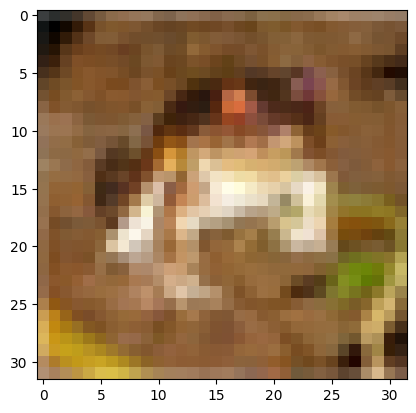

(32, 32, 3)
frog


In [15]:
# a function to show an image
def show_image(image):
    # convert the 3,072 length list to a 3D array
    img = image.reshape(3, 32, 32)

    # change the order of the dimensions
    img = img.transpose(1, 2, 0)

    # show the image
    plt.imshow(img)

    # allow multiple images to be shown from one cell
    plt.show()

    print(img.shape)

show_image(image_data[0])
print(label_names[label_data[0]])

### Train test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(image_data, label_data, random_state=42)

X_train.shape

(7500, 3072)

### Train Default Neural Network

In [17]:
# define the model
clf = MLPClassifier(random_state=42)

# train the model
clf.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [18]:
# look at the accuracy
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

acc

0.094

### Test how Hidden Layers Affects Accuracy

In [23]:
# make a list of hidden layer shapes to test
hidden_layer_shapes = [
    (50,), # 1 layer with 50 nodes
    (100,), # 1 layer with 100 nodes
    (50, 50), # 2 layers each with 50 nodes
    (100, 100), # 2 layers each with 100 nodes
    (50, 50, 50), # 3 layers each with 50 nodes
    (100, 100, 100), # 3 layers each with 100 nodes
]

# loop over the different shapes
for shape in hidden_layer_shapes:
    # define the model
    clf = MLPClassifier(hidden_layer_sizes=shape, random_state=42)

    # train the model
    clf.fit(X_train, y_train)

    # make test set predictions
    y_pred = clf.predict(X_test)

    # get the accuracy
    acc = accuracy_score(y_test, y_pred)

    print(shape, acc)

(50,) 0.094
(100,) 0.094
(50, 50) 0.094
(100, 100) 0.3308
(50, 50, 50) 0.2556
(100, 100, 100) 0.3728


## Activity: What is the Effect of the Activation Function
Try testing different values for the activation parameter: 'identity', 'logistic', 'tanh', 'relu'

Make a bar graph showing the test set accuracy with the four different parameters

In [28]:
parameters = ['identity', 'logistic', 'tanh', 'relu']

acc_list = []

# loop over the different parameters
for param in parameters:
    # define the model
    clf = MLPClassifier(hidden_layer_sizes=(100, 100), random_state=42, activation=param)

    # train the model
    clf.fit(X_train, y_train)

    # make test set predictions
    y_pred = clf.predict(X_test)

    # get the accuracy
    acc = accuracy_score(y_test, y_pred)

    # put accuracies into list for plot
    acc_list.append(acc)

    print(param, acc)


identity 0.3208
logistic 0.1008
tanh 0.0976
relu 0.3308


(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.1, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20'),
  Text(0, 0.25, '0.25'),
  Text(0, 0.30000000000000004, '0.30'),
  Text(0, 0.35000000000000003, '0.35')])

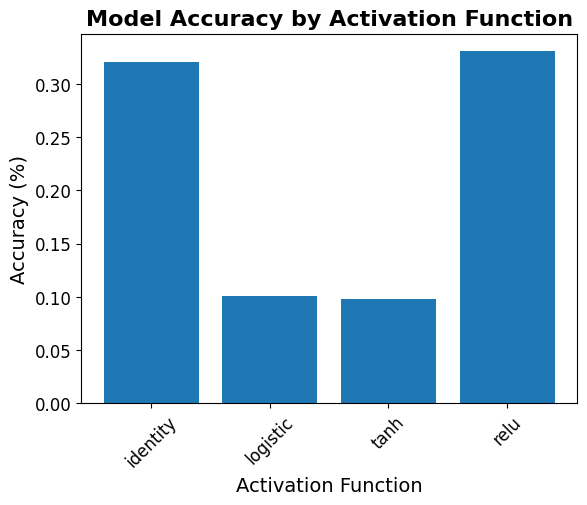

In [29]:
plt.bar(parameters, acc_list)
plt.title("Model Accuracy by Activation Function", size=16, fontweight='bold')
plt.xlabel("Activation Function", size=14)
plt.ylabel("Accuracy (%)", size=14)
plt.xticks(size=12, rotation=45)
plt.yticks(size=12)